LOADING DATA

Dataset loaded successfully!
Rows    : 700
Columns : 16

FIRST 5 RECORDS
      Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera           NaN      1513.0   
1  Government  Germany      Paseo           NaN      1006.0   
2  Government   Canada      Paseo           NaN      1725.0   
3  Government  Germany      Paseo           NaN      1513.0   
4  Government  Germany       Velo           NaN      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit       Date  Month Number Month Name  Year  
0  393380.0  136170.0 2014-12-01   

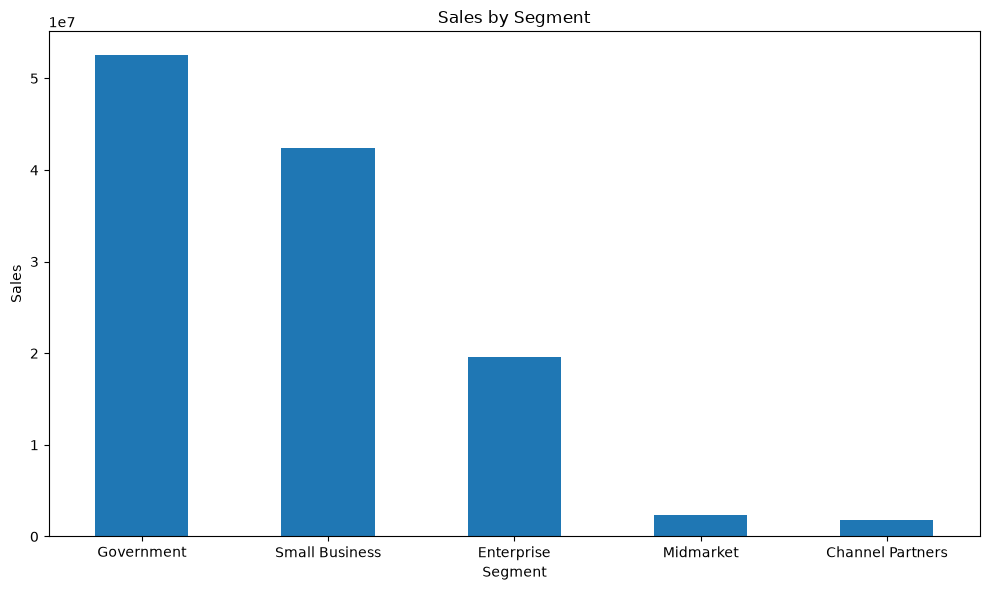

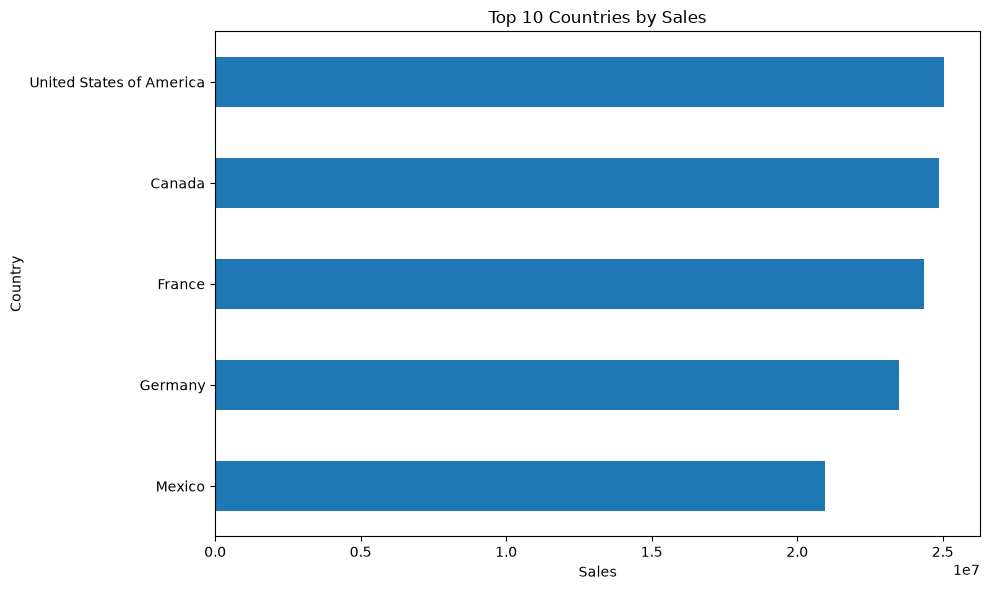

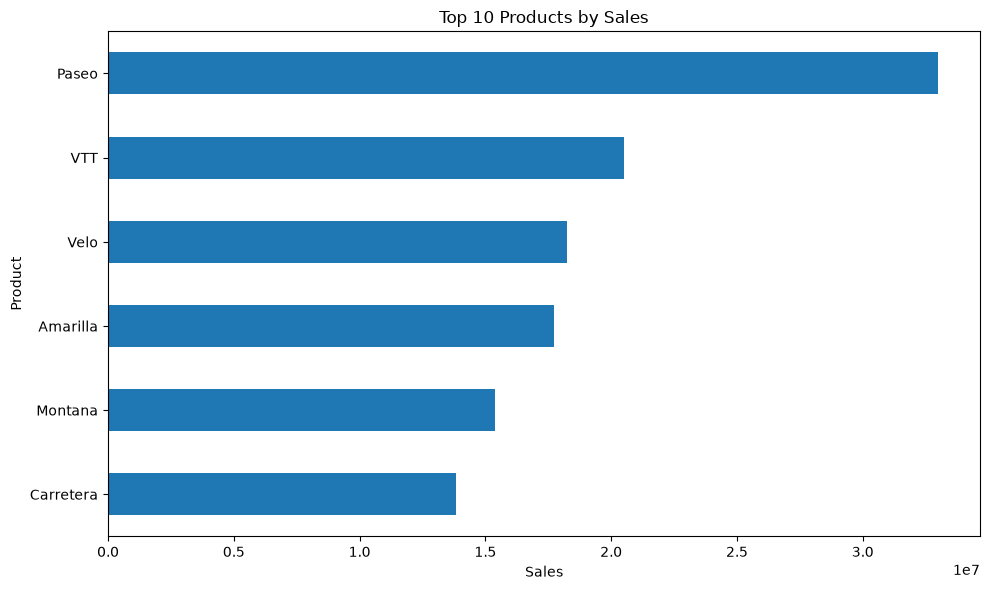

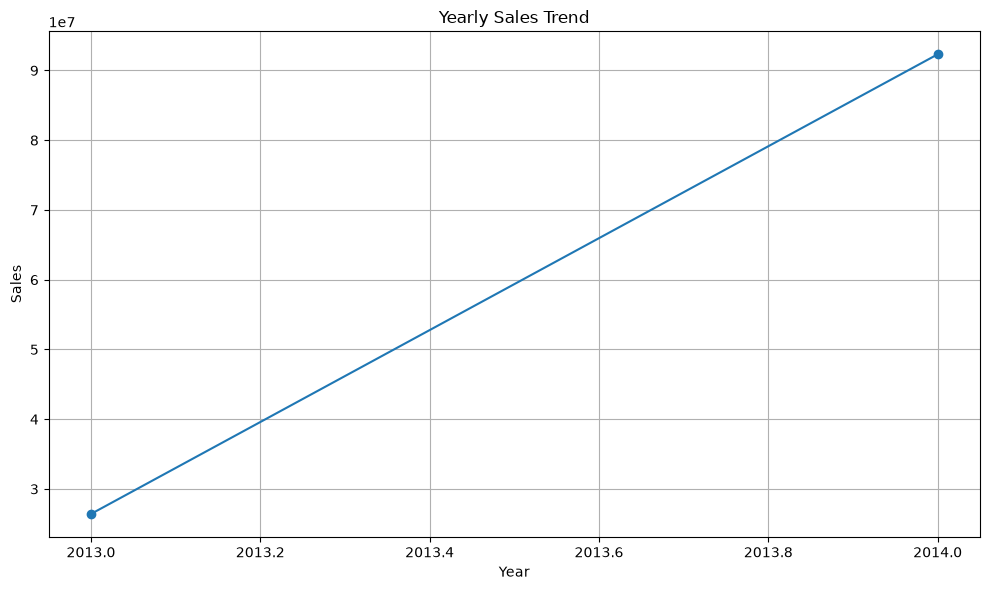

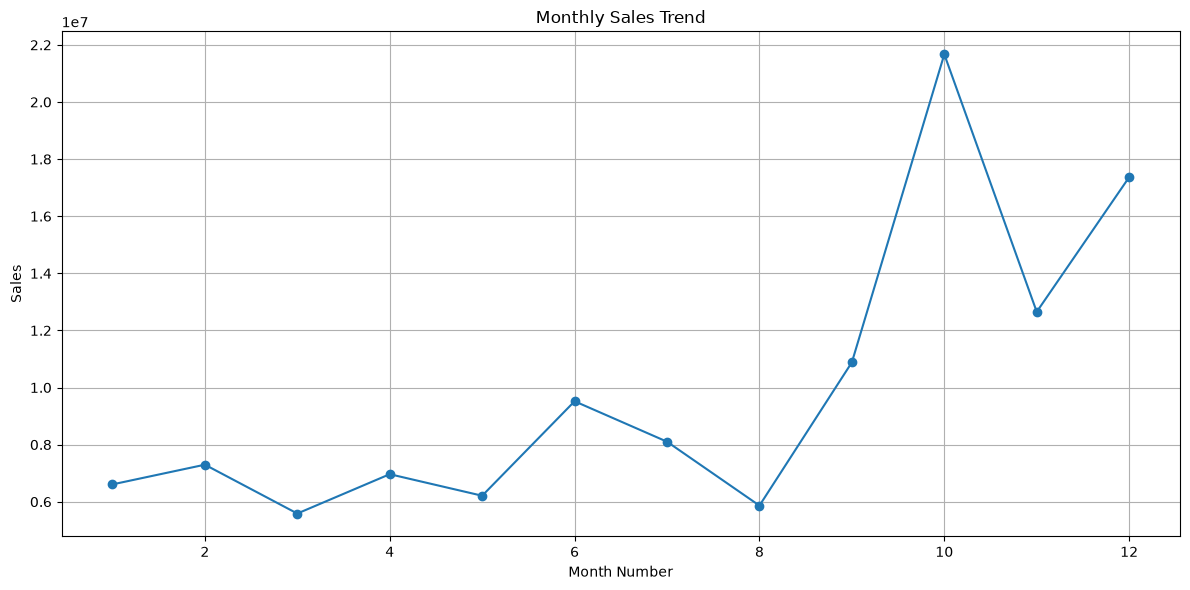

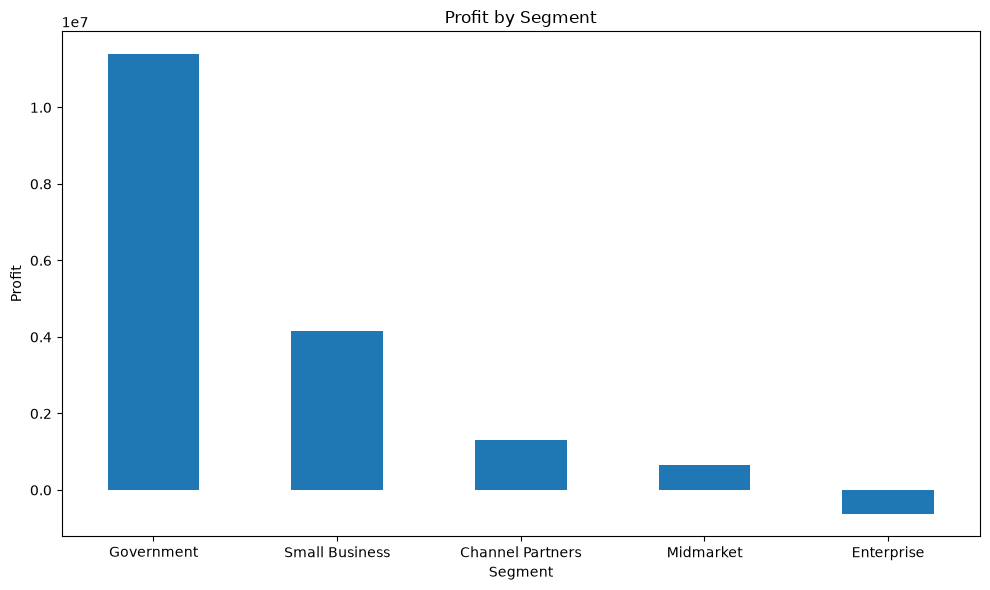

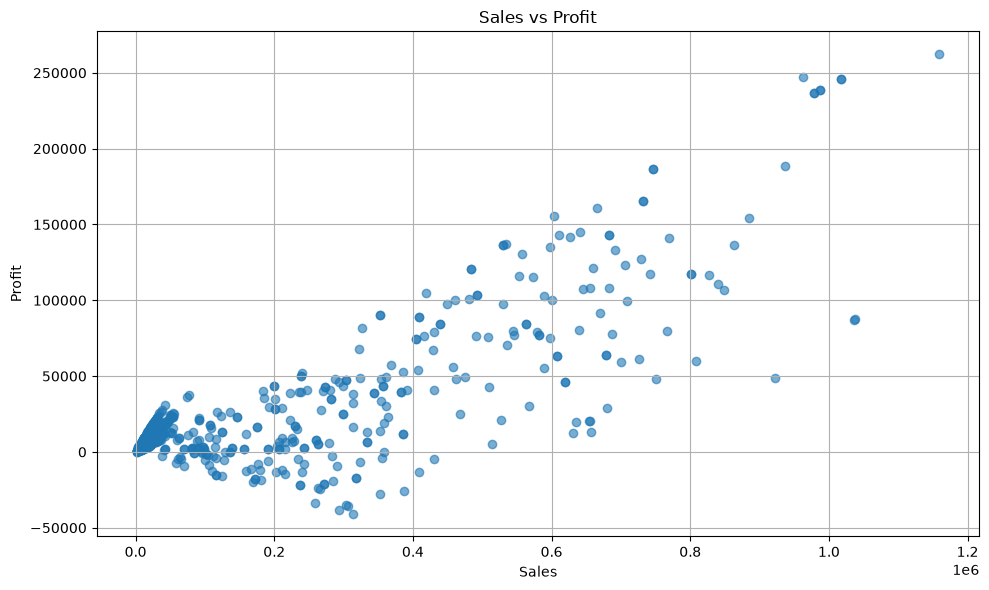

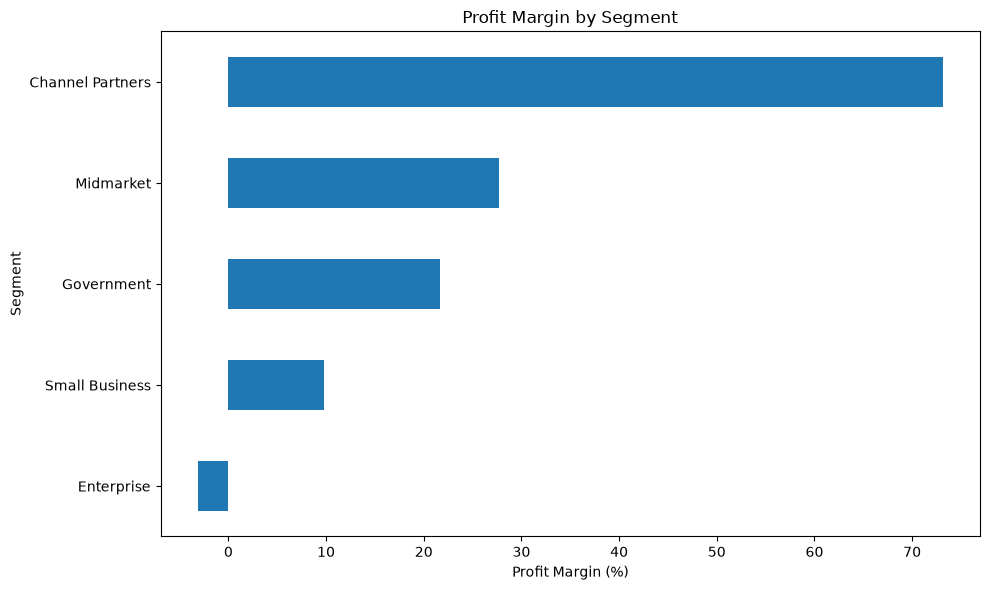


Cleaned dataset exported to:
analysis_output\Cleaned_Sales_Data.xlsx

KEY DATA-DRIVEN INSIGHTS
1. Highest-sales segment: Government
2. Highest-sales country: United States of America
3. Highest-sales product: Paseo
4. Most profitable product: Paseo
5. Highest-sales year: 2014
6. Highest-profit year: 2014
7. Lowest-profit product: Carretera
8. Highest-margin segment: Channel Partners

ANALYSIS COMPLETED SUCCESSFULLY

Files created inside:
analysis_output

Generated files include:
1. Cleaned_Sales_Data.xlsx
2. Sales_Analysis_Results.xlsx
3. Business_Insights.txt
4. sales_by_segment.png
5. top_10_countries_sales.png
6. top_10_products_sales.png
7. yearly_sales_trend.png
8. monthly_sales_trend.png
9. profit_by_segment.png
10. sales_vs_profit.png
11. profit_margin_by_segment.png

Next step:
Import Cleaned_Sales_Data.xlsx into Excel and Power BI.


In [2]:
# ============================================================
# END-TO-END SALES DATA ANALYSIS
# Dataset: Raw_Data.xlsx
# Tool: Python / Pandas / Matplotlib
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 2. FILE PATHS
# ============================================================

# Change this path if your Excel file is located somewhere else
FILE_PATH = r"C:\Users\gupta\OneDrive\Desktop\End-to-End-Sales-Analysis\Data\Raw_Data.xlsx"

# Folder where outputs will be saved
OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# 3. LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

df = pd.read_excel(FILE_PATH, sheet_name="Sheet1")

print("\nDataset loaded successfully!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


# ============================================================
# 4. DISPLAY BASIC INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)

print(df.head())


print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(df.columns.tolist())


print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)


print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.info())


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("\nCleaned column names:")
print(df.columns.tolist())


# ============================================================
# 6. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")


# ============================================================
# 7. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)


# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

# Fill categorical missing values
categorical_columns = [
    "Segment",
    "Country",
    "Product",
    "Discount Band",
    "Month Name"
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")


# Fill numerical missing values with 0
numeric_columns = [
    "Units Sold",
    "Manufacturing Price",
    "Sale Price",
    "Gross Sales",
    "Discounts",
    "Sales",
    "COGS",
    "Profit"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = df[column].fillna(0)


# ============================================================
# 9. CONVERT DATE COLUMN
# ============================================================

if "Date" in df.columns:

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    print("\nDate column converted successfully.")


# ============================================================
# 10. CONVERT NUMERIC COLUMNS
# ============================================================

for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# ============================================================
# 11. CREATE ADDITIONAL FEATURES
# ============================================================

print("\n" + "=" * 60)
print("CREATING ADDITIONAL FEATURES")
print("=" * 60)


# Year
if "Date" in df.columns:
    df["Year"] = df["Date"].dt.year


# Month Number
if "Date" in df.columns:
    df["Month Number"] = df["Date"].dt.month


# Month Name
if "Date" in df.columns:
    df["Month Name"] = df["Date"].dt.month_name()


# Profit Margin
if "Sales" in df.columns and "Profit" in df.columns:

    df["Profit Margin %"] = np.where(
        df["Sales"] != 0,
        (df["Profit"] / df["Sales"]) * 100,
        0
    )


# Discount %
if "Gross Sales" in df.columns and "Discounts" in df.columns:

    df["Discount %"] = np.where(
        df["Gross Sales"] != 0,
        (df["Discounts"] / df["Gross Sales"]) * 100,
        0
    )


# ============================================================
# 12. FINAL DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATA QUALITY CHECK")
print("=" * 60)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ============================================================
# 13. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(df.describe())


# ============================================================
# 14. KPI ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("KEY PERFORMANCE INDICATORS")
print("=" * 60)


total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_units = df["Units Sold"].sum()

total_gross_sales = df["Gross Sales"].sum()

total_discounts = df["Discounts"].sum()

total_cogs = df["COGS"].sum()

average_sale = df["Sales"].mean()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0
    else 0
)


print(f"Total Sales       : {total_sales:,.2f}")
print(f"Total Profit      : {total_profit:,.2f}")
print(f"Total Units Sold  : {total_units:,.0f}")
print(f"Gross Sales       : {total_gross_sales:,.2f}")
print(f"Total Discounts   : {total_discounts:,.2f}")
print(f"Total COGS        : {total_cogs:,.2f}")
print(f"Average Sale      : {average_sale:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")


# ============================================================
# 15. SALES BY SEGMENT
# ============================================================

print("\n" + "=" * 60)
print("SALES BY SEGMENT")
print("=" * 60)

segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)


# ============================================================
# 16. PROFIT BY SEGMENT
# ============================================================

segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nProfit by Segment:")
print(segment_profit)


# ============================================================
# 17. SALES BY COUNTRY
# ============================================================

print("\n" + "=" * 60)
print("TOP COUNTRIES BY SALES")
print("=" * 60)

country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(country_sales.head(10))


# ============================================================
# 18. PROFIT BY COUNTRY
# ============================================================

country_profit = (
    df.groupby("Country")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Countries by Profit:")
print(country_profit.head(10))


# ============================================================
# 19. SALES BY PRODUCT
# ============================================================

print("\n" + "=" * 60)
print("TOP PRODUCTS BY SALES")
print("=" * 60)

product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales.head(10))


# ============================================================
# 20. PROFIT BY PRODUCT
# ============================================================

product_profit = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Products by Profit:")
print(product_profit.head(10))


# ============================================================
# 21. UNITS SOLD BY PRODUCT
# ============================================================

product_units = (
    df.groupby("Product")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Products by Units Sold:")
print(product_units.head(10))


# ============================================================
# 22. SALES BY YEAR
# ============================================================

print("\n" + "=" * 60)
print("YEARLY SALES")
print("=" * 60)

year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .sort_index()
)

print(year_sales)


# ============================================================
# 23. PROFIT BY YEAR
# ============================================================

year_profit = (
    df.groupby("Year")["Profit"]
    .sum()
    .sort_index()
)

print("\nYearly Profit:")
print(year_profit)


# ============================================================
# 24. MONTHLY SALES
# ============================================================

monthly_sales = (
    df.groupby("Month Number")["Sales"]
    .sum()
    .sort_index()
)

print("\n" + "=" * 60)
print("MONTHLY SALES")
print("=" * 60)

print(monthly_sales)


# ============================================================
# 25. DISCOUNT ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("DISCOUNT ANALYSIS")
print("=" * 60)

discount_analysis = (
    df.groupby("Discount Band")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Discounts=("Discounts", "sum")
    )
    .sort_values("Sales", ascending=False)
)

print(discount_analysis)


# ============================================================
# 26. PROFIT MARGIN BY PRODUCT
# ============================================================

product_profit_margin = (
    df.groupby("Product")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

product_profit_margin["Profit Margin %"] = np.where(
    product_profit_margin["Sales"] != 0,
    product_profit_margin["Profit"]
    / product_profit_margin["Sales"] * 100,
    0
)

product_profit_margin = (
    product_profit_margin
    .sort_values("Profit Margin %", ascending=False)
)

print("\n" + "=" * 60)
print("PRODUCT PROFIT MARGIN")
print("=" * 60)

print(product_profit_margin.head(10))


# ============================================================
# 27. SEGMENT PERFORMANCE SUMMARY
# ============================================================

segment_summary = (
    df.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum"),
        Average_Sale=("Sales", "mean")
    )
)

segment_summary["Profit Margin %"] = np.where(
    segment_summary["Sales"] != 0,
    segment_summary["Profit"]
    / segment_summary["Sales"] * 100,
    0
)

print("\n" + "=" * 60)
print("SEGMENT PERFORMANCE")
print("=" * 60)

print(segment_summary)


# ============================================================
# 28. COUNTRY PERFORMANCE SUMMARY
# ============================================================

country_summary = (
    df.groupby("Country")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
)

country_summary["Profit Margin %"] = np.where(
    country_summary["Sales"] != 0,
    country_summary["Profit"]
    / country_summary["Sales"] * 100,
    0
)

country_summary = country_summary.sort_values(
    "Sales",
    ascending=False
)

print("\n" + "=" * 60)
print("COUNTRY PERFORMANCE")
print("=" * 60)

print(country_summary.head(10))


# ============================================================
# 29. TOP 10 PRODUCTS
# ============================================================

top_10_products = (
    df.groupby("Product")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .sort_values("Sales", ascending=False)
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 PRODUCTS")
print("=" * 60)

print(top_10_products)


# ============================================================
# 30. LOW-PROFIT PRODUCTS
# ============================================================

low_profit_products = (
    df.groupby("Product")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit", ascending=True)
    .head(10)
)

print("\n" + "=" * 60)
print("LOWEST PROFIT PRODUCTS")
print("=" * 60)

print(low_profit_products)


# ============================================================
# 31. SALES VS PROFIT CORRELATION
# ============================================================

correlation = df[["Sales", "Profit"]].corr()

print("\n" + "=" * 60)
print("SALES VS PROFIT CORRELATION")
print("=" * 60)

print(correlation)


# ============================================================
# 32. VISUALIZATION 1
# SALES BY SEGMENT
# ============================================================

plt.figure(figsize=(10, 6))

segment_sales.plot(kind="bar")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_by_segment.png",
    dpi=300
)

plt.show()


# ============================================================
# 33. VISUALIZATION 2
# SALES BY COUNTRY
# ============================================================

top_countries = country_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_countries.plot(kind="barh")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_10_countries_sales.png",
    dpi=300
)

plt.show()


# ============================================================
# 34. VISUALIZATION 3
# TOP 10 PRODUCTS
# ============================================================

top_products_chart = (
    product_sales
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_products_chart.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_10_products_sales.png",
    dpi=300
)

plt.show()


# ============================================================
# 35. VISUALIZATION 4
# YEARLY SALES TREND
# ============================================================

plt.figure(figsize=(10, 6))

year_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "yearly_sales_trend.png",
    dpi=300
)

plt.show()


# ============================================================
# 36. VISUALIZATION 5
# MONTHLY SALES TREND
# ============================================================

plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month Number")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "monthly_sales_trend.png",
    dpi=300
)

plt.show()


# ============================================================
# 37. VISUALIZATION 6
# PROFIT BY SEGMENT
# ============================================================

plt.figure(figsize=(10, 6))

segment_profit.plot(kind="bar")

plt.title("Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "profit_by_segment.png",
    dpi=300
)

plt.show()


# ============================================================
# 38. VISUALIZATION 7
# SALES VS PROFIT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_vs_profit.png",
    dpi=300
)

plt.show()


# ============================================================
# 39. VISUALIZATION 8
# PROFIT MARGIN BY SEGMENT
# ============================================================

segment_margin = segment_summary["Profit Margin %"].sort_values()

plt.figure(figsize=(10, 6))

segment_margin.plot(kind="barh")

plt.title("Profit Margin by Segment")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Segment")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "profit_margin_by_segment.png",
    dpi=300
)

plt.show()


# ============================================================
# 40. EXPORT CLEANED DATA
# ============================================================

cleaned_file = OUTPUT_DIR / "Cleaned_Sales_Data.xlsx"

df.to_excel(
    cleaned_file,
    index=False
)

print("\nCleaned dataset exported to:")
print(cleaned_file)


# ============================================================
# 41. EXPORT ANALYSIS RESULTS
# ============================================================

analysis_file = OUTPUT_DIR / "Sales_Analysis_Results.xlsx"

with pd.ExcelWriter(
    analysis_file,
    engine="openpyxl"
) as writer:

    # KPIs
    kpi_data = pd.DataFrame({
        "Metric": [
            "Total Sales",
            "Total Profit",
            "Total Units Sold",
            "Gross Sales",
            "Discounts",
            "COGS",
            "Average Sale",
            "Profit Margin %"
        ],
        "Value": [
            total_sales,
            total_profit,
            total_units,
            total_gross_sales,
            total_discounts,
            total_cogs,
            average_sale,
            profit_margin
        ]
    })

    kpi_data.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    segment_summary.to_excel(
        writer,
        sheet_name="Segment Analysis"
    )

    country_summary.to_excel(
        writer,
        sheet_name="Country Analysis"
    )

    top_10_products.to_excel(
        writer,
        sheet_name="Top Products"
    )

    year_sales.to_frame(
        "Sales"
    ).to_excel(
        writer,
        sheet_name="Yearly Sales"
    )

    year_profit.to_frame(
        "Profit"
    ).to_excel(
        writer,
        sheet_name="Yearly Profit"
    )

    monthly_sales.to_frame(
        "Sales"
    ).to_excel(
        writer,
        sheet_name="Monthly Sales"
    )

    discount_analysis.to_excel(
        writer,
        sheet_name="Discount Analysis"
    )

    product_profit_margin.to_excel(
        writer,
        sheet_name="Product Margins"
    )


# ============================================================
# 42. AUTOMATIC INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("KEY DATA-DRIVEN INSIGHTS")
print("=" * 60)


# Highest sales segment
best_segment = segment_sales.idxmax()

print(
    f"1. Highest-sales segment: "
    f"{best_segment}"
)


# Highest sales country
best_country = country_sales.idxmax()

print(
    f"2. Highest-sales country: "
    f"{best_country}"
)


# Best product
best_product = product_sales.idxmax()

print(
    f"3. Highest-sales product: "
    f"{best_product}"
)


# Most profitable product
best_profit_product = product_profit.idxmax()

print(
    f"4. Most profitable product: "
    f"{best_profit_product}"
)


# Best year
best_year = year_sales.idxmax()

print(
    f"5. Highest-sales year: "
    f"{best_year}"
)


# Highest profit year
best_profit_year = year_profit.idxmax()

print(
    f"6. Highest-profit year: "
    f"{best_profit_year}"
)


# Lowest profit product
worst_product = product_profit.idxmin()

print(
    f"7. Lowest-profit product: "
    f"{worst_product}"
)


# Best margin segment
best_margin_segment = segment_summary[
    "Profit Margin %"
].idxmax()

print(
    f"8. Highest-margin segment: "
    f"{best_margin_segment}"
)


# ============================================================
# 43. SAVE TEXT SUMMARY
# ============================================================

summary_file = OUTPUT_DIR / "Business_Insights.txt"

with open(summary_file, "w", encoding="utf-8") as file:

    file.write("SALES ANALYSIS - BUSINESS INSIGHTS\n")
    file.write("=" * 50 + "\n\n")

    file.write(
        f"Total Sales: {total_sales:,.2f}\n"
    )

    file.write(
        f"Total Profit: {total_profit:,.2f}\n"
    )

    file.write(
        f"Total Units Sold: {total_units:,.0f}\n"
    )

    file.write(
        f"Profit Margin: {profit_margin:.2f}%\n\n"
    )

    file.write(
        f"Highest-sales segment: {best_segment}\n"
    )

    file.write(
        f"Highest-sales country: {best_country}\n"
    )

    file.write(
        f"Highest-sales product: {best_product}\n"
    )

    file.write(
        f"Most profitable product: {best_profit_product}\n"
    )

    file.write(
        f"Highest-sales year: {best_year}\n"
    )

    file.write(
        f"Highest-profit year: {best_profit_year}\n"
    )

    file.write(
        f"Lowest-profit product: {worst_product}\n"
    )

    file.write(
        f"Highest-margin segment: {best_margin_segment}\n"
    )


# ============================================================
# 44. FINAL MESSAGE
# ============================================================

print("\n" + "=" * 60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nFiles created inside:")
print(OUTPUT_DIR)

print("\nGenerated files include:")

print("1. Cleaned_Sales_Data.xlsx")
print("2. Sales_Analysis_Results.xlsx")
print("3. Business_Insights.txt")
print("4. sales_by_segment.png")
print("5. top_10_countries_sales.png")
print("6. top_10_products_sales.png")
print("7. yearly_sales_trend.png")
print("8. monthly_sales_trend.png")
print("9. profit_by_segment.png")
print("10. sales_vs_profit.png")
print("11. profit_margin_by_segment.png")

print("\nNext step:")
print("Import Cleaned_Sales_Data.xlsx into Excel and Power BI.")